# 02 · Sparse reconstruction of a dense map (paper Figs 2–3, SCM-PIT-A Dense_Grid_B)

Ground truth: 241 positions, 4.7 h, 1.5 µN, InvOLS-ruler axis. Every reconstruction
sees only the selected positions; errors are scored on the **held-out** positions.

Arms computed here: model-free **GP** (the draft's arm, `recon.rec_gp`) and
**low-rank** Chebyshev (`activemodemap.lowrank`). The draft's **EB+GP** arm needs
the two-segment EB library binding and is read from the archived tables
(`fmmpaper.published`), so published and recomputed numbers sit on one plot.

In [1]:
%matplotlib inline
import sys, pathlib
# make the paper package importable when running from notebooks/
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import fmmpaper as F
from fmmpaper import io, axis, spectra, domains, recon, plotting as fp, results
fp.setup()
print(F.config.describe())

project : C:\Users\lz1\Documents\Github\ActiveModeMap_repo\ActiveModeMap\paper_analysis
data_root: D:\ActiveModeMap  (ok)
amm_repo : C:\Users\lz1\Documents\Github\ActiveModeMap_repo\ActiveModeMap  (ok)
eb_repo  : C:\Users\lz1\Documents\Github\EB-Solver-CResonance  (ok)
fmm_code_zip: C:\Users\lz1\Documents\Github\ActiveModeMap_repo\Manuscript_FMM\FMM_analysis_code.zip  (ok)


In [2]:
from fmmpaper import published
g = F.load("scmpitA_gridB")
x = g.meta['x_true_um']; f = g.freq_Hz; Z = g.Z[0]
X_TIP = 221.9                         # node-fit tip position, draft Sec. S2
mA = g.band("CR1")                    # 'mode A' band, 250-400 kHz
f0, v_res = spectra.on_resonance_profile(f, Z, g.probe.bands_Hz['CR1'])
dns_true = spectra.dns_signed(x, v_res)
print(f"mode-A resonance {f0/1e3:.2f} kHz; D-NS (dense) = {dns_true['dns']:.2f} um "
      f"(draft: 224.11 um); crossings {np.round(dns_true['crossings'], 2)}")

mode-A resonance 293.23 kHz; D-NS (dense) = 224.11 um (draft: 224.11 um); crossings [224.11]


## Check: recomputed GP arm reproduces the archived draft numbers

In [3]:
reg = published.load("regen")
pub_gp = reg.query("arm == 'gp' and strategy == 'equispaced'").set_index('n').nrmse_A
chk = []
for n in pub_gp.index:
    sel = recon.select_equispaced(x, n); h = recon.held_out(len(x), sel)
    r = recon.rec_gp(x, sel, Z[sel])
    chk.append(dict(n=n, recomputed=recon.nrmse(r['Zrec'][h], Z[h], mA), published=pub_gp[n]))
chk = pd.DataFrame(chk); chk['diff'] = chk.recomputed - chk.published
chk.round(3)

,n,recomputed,published,diff
0,3,44.955,44.955,-0.0
1,4,44.070,44.070,0.0
2,5,7.231,7.231,-0.0
3,6,6.611,6.611,-0.0
4,8,6.648,6.648,-0.0
5,12,6.715,6.715,-0.0
6,20,5.532,5.532,0.0


## Reconstructed maps at N = 3 and N = 6 (equispaced)

[WindowsPath('C:/Users/lz1/Documents/Github/ActiveModeMap_repo/ActiveModeMap/paper_analysis/figures/02_maps_N3_N6.png'),
 WindowsPath('C:/Users/lz1/Documents/Github/ActiveModeMap_repo/ActiveModeMap/paper_analysis/figures/02_maps_N3_N6.pdf')]

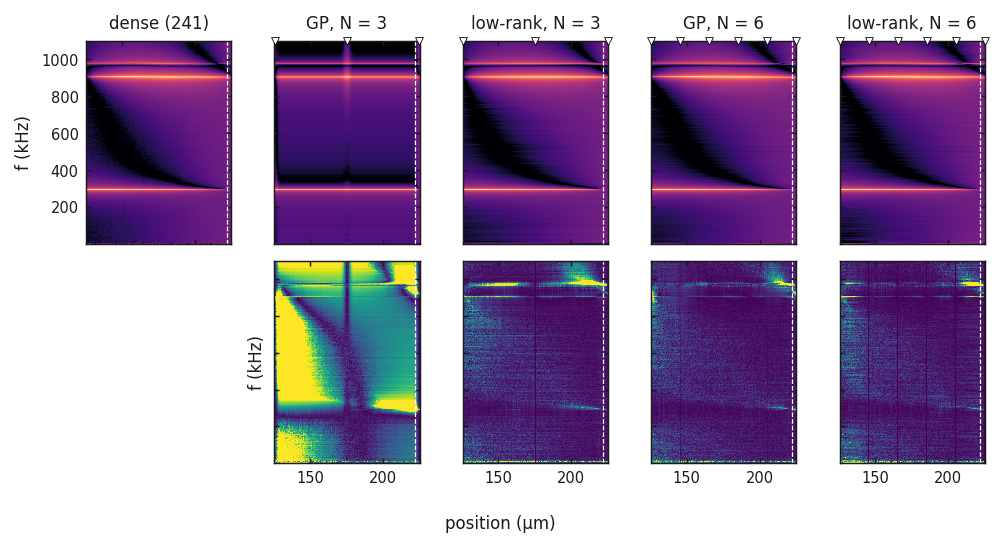

In [4]:
def floored_rel_err(Zr, Zt):
    # draft Sec. S5: |Zr - Z| / max(|Z|, 0.1 * RMS_f |Z(x, .)|)
    rms = np.sqrt(np.mean(np.abs(Zt) ** 2, axis=1, keepdims=True))
    return np.abs(Zr - Zt) / np.maximum(np.abs(Zt), 0.1 * rms)

fmax = 1100
recs = {}
for n in (3, 6):
    sel = recon.select_equispaced(x, n)
    recs[('GP', n)] = (sel, recon.rec_gp(x, sel, Z[sel]))
    recs[('low-rank', n)] = (sel, recon.rec_lowrank(x, sel, Z[sel], rank=n))

fig, axs = plt.subplots(2, 5, figsize=(fp.WIDTH_IN['double'], 3.6), sharex=True, sharey=True)
ref = np.abs(Z).max()
fp.map_db(axs[0, 0], x, f, Z, ref=ref, fmax=fmax, colorbar=False); axs[0, 0].set_title("dense (241)")
axs[1, 0].axis('off')
for c, key in enumerate([('GP', 3), ('low-rank', 3), ('GP', 6), ('low-rank', 6)], start=1):
    sel, r = recs[key]
    fp.map_db(axs[0, c], x, f, r['Zrec'], ref=ref, fmax=fmax, colorbar=False)
    fp.mark_positions(axs[0, c], x[sel])
    axs[0, c].set_title(f"{key[0]}, N = {key[1]}")
    E = floored_rel_err(r['Zrec'], Z)
    m = f / 1e3 <= fmax
    axs[1, c].pcolormesh(x, f[m] / 1e3, E[:, m].T, cmap='viridis', vmin=0, vmax=1, shading='nearest', rasterized=True)
for ax in axs.flat:
    ax.set_xlabel(""); ax.set_ylabel("")
    ax.axvline(X_TIP, color='w', ls='--', lw=0.6)
axs[0, 0].set_ylabel("f (kHz)"); axs[1, 1].set_ylabel("f (kHz)")
fig.supxlabel("position (µm)", fontsize=8)
fig.tight_layout()
fp.save(fig, "02_maps_N3_N6")

## Spectra at withheld positions: interior → near tip → D-NS

[WindowsPath('C:/Users/lz1/Documents/Github/ActiveModeMap_repo/ActiveModeMap/paper_analysis/figures/02_withheld_spectra.png'),
 WindowsPath('C:/Users/lz1/Documents/Github/ActiveModeMap_repo/ActiveModeMap/paper_analysis/figures/02_withheld_spectra.pdf')]

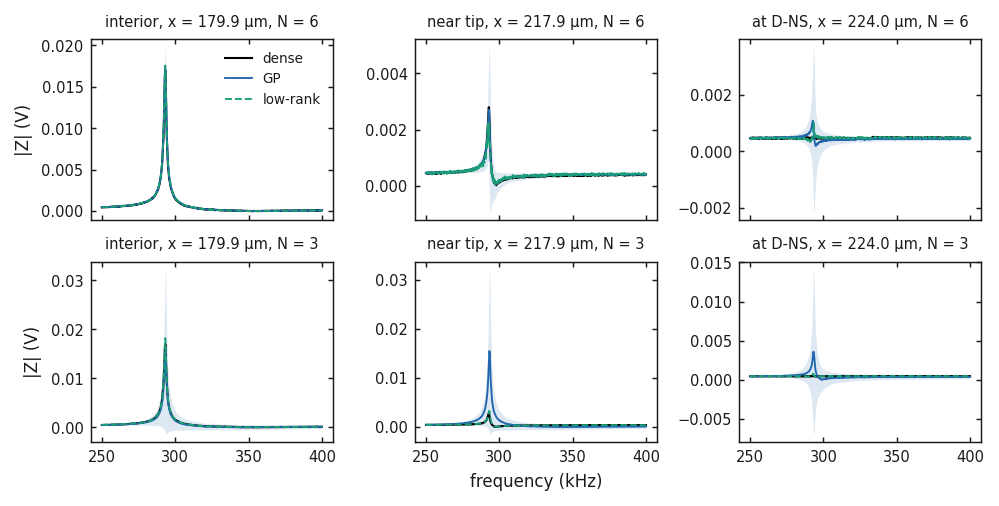

In [5]:
targets = {"interior": 180.0, "near tip": 217.9, "at D-NS": dns_true['dns']}
fig, axs = plt.subplots(2, 3, figsize=(fp.WIDTH_IN['double'], 3.4), sharex=True)
fb = (f > 250e3) & (f < 400e3)
for c, (lab, xt) in enumerate(targets.items()):
    for row, n in enumerate((6, 3)):
        ax = axs[row, c]
        sel_gp, rgp = recs[('GP', n)]; _, rlr = recs[('low-rank', n)]
        j = int(np.argmin(np.abs(x - xt)))
        while j in sel_gp:
            j += 1
        ax.plot(f[fb]/1e3, np.abs(Z[j, fb]), color=fp.C['meas'], lw=1.0, label='dense')
        ax.plot(f[fb]/1e3, np.abs(rgp['Zrec'][j, fb]), color=fp.C['gp'], lw=0.9, label='GP')
        ax.fill_between(f[fb]/1e3, np.abs(rgp['Zrec'][j, fb]) - 2*rgp['sd'][j, fb],
                        np.abs(rgp['Zrec'][j, fb]) + 2*rgp['sd'][j, fb], color=fp.C['gp'], alpha=0.15, lw=0)
        ax.plot(f[fb]/1e3, np.abs(rlr['Zrec'][j, fb]), color=fp.C['lowrank'], lw=0.9, ls='--', label='low-rank')
        ax.set_title(f"{lab}, x = {x[j]:.1f} µm, N = {n}", fontsize=7)
axs[0, 0].legend(); axs[1, 1].set_xlabel("frequency (kHz)")
axs[0, 0].set_ylabel("|Z| (V)"); axs[1, 0].set_ylabel("|Z| (V)")
fig.tight_layout(); fp.save(fig, "02_withheld_spectra")

## Error vs number of positions (paper Fig. 3a)
GP and low-rank recomputed here (equispaced + 20 random draws for the GP band);
EB+GP (equispaced, small-N variant at N = 3–4) and the oracle read from the archived tables.

In [6]:
rng = np.random.default_rng(0)
NS = [3, 4, 5, 6, 8, 12, 20]
rows = []
for n in NS:
    sel = recon.select_equispaced(x, n); h = recon.held_out(len(x), sel)
    for arm, r in (("GP", recon.rec_gp(x, sel, Z[sel])),
                   ("low-rank r=N", recon.rec_lowrank(x, sel, Z[sel], rank=n)),
                   ("low-rank r=4", recon.rec_lowrank(x, sel, Z[sel], rank=min(4, n)))):
        dn = spectra.dns_signed(x, r['Zrec'][:, int(np.argmin(np.abs(f - f0)))])
        rows.append(dict(n=n, arm=arm, nrmse_A=recon.nrmse(r['Zrec'][h], Z[h], mA),
                         nrmse_full=recon.nrmse(r['Zrec'][h], Z[h]),
                         dns=dn['dns'], dns_err=abs(dn['dns'] - dns_true['dns'])))
    for t in range(20):
        sel = recon.select_random(x, n, rng); h = recon.held_out(len(x), sel)
        r = recon.rec_gp(x, sel, Z[sel])
        rows.append(dict(n=n, arm="GP random", nrmse_A=recon.nrmse(r['Zrec'][h], Z[h], mA),
                         nrmse_full=recon.nrmse(r['Zrec'][h], Z[h])))
sweep = pd.DataFrame(rows)
ebgp = reg.query("strategy == 'equispaced' and arm in ['eb_gp', 'ebgp3']")
ebgp = ebgp.sort_values('arm').groupby('n').last()   # ebgp3 (small-N variant) wins at N = 3, 4
orc = published.load("oracle").query("axis == 'C' and objective == 'global'")
sweep.query("arm != 'GP random'").pivot(index='n', columns='arm', values='nrmse_A').round(2)

arm,GP,low-rank r=4,low-rank r=N
n,,,
3,44.96,10.15,10.15
4,44.07,8.64,8.64
5,7.23,6.74,8.32
6,6.61,7.16,6.80
8,6.65,6.86,9.17
12,6.71,7.02,38.88
20,5.53,6.21,2149.05


[WindowsPath('C:/Users/lz1/Documents/Github/ActiveModeMap_repo/ActiveModeMap/paper_analysis/figures/02_error_vs_N.png'),
 WindowsPath('C:/Users/lz1/Documents/Github/ActiveModeMap_repo/ActiveModeMap/paper_analysis/figures/02_error_vs_N.pdf')]

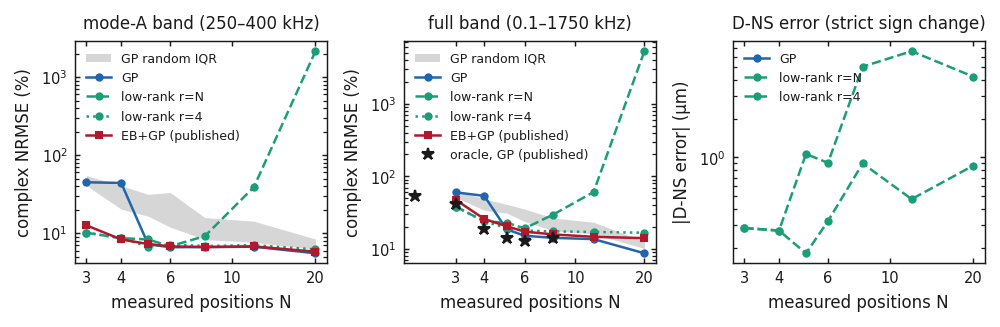

In [7]:
fig, axs = fp.figure("double", aspect=0.33, ncols=3)
rnd = sweep.query("arm == 'GP random'").groupby('n')
for ax, col, title in ((axs[0], 'nrmse_A', 'mode-A band (250–400 kHz)'),
                       (axs[1], 'nrmse_full', 'full band (0.1–1750 kHz)')):
    q = rnd[col].quantile([.25, .5, .75]).unstack()
    ax.fill_between(q.index, q[.25], q[.75], color=fp.C['random'], alpha=0.6, lw=0, label='GP random IQR')
    for arm, c, ls in (("GP", fp.C['gp'], '-'), ("low-rank r=N", fp.C['lowrank'], '--'),
                       ("low-rank r=4", fp.C['lowrank'], ':')):
        d = sweep.query("arm == @arm")
        ax.plot(d.n, d[col], ls, color=c, marker='o', ms=3, label=arm)
    fp.n_axis(ax); ax.set_yscale('log'); ax.set_title(title)
    ax.set_xlabel("measured positions N"); ax.set_ylabel("complex NRMSE (%)")
axs[0].plot(ebgp.index, ebgp.nrmse_A, '-', color=fp.C['ebgp'], marker='s', ms=3, label='EB+GP (published)')
axs[1].plot(ebgp.index, ebgp.nrmse_cplx, '-', color=fp.C['ebgp'], marker='s', ms=3, label='EB+GP (published)')
axs[1].plot(orc.n, orc.e_global, '*', color=fp.C['oracle'], ms=6, label='oracle, GP (published)')
axs[0].legend(fontsize=6); axs[1].legend(fontsize=6)
ok = sweep.dropna(subset=['dns'])
for arm, c in (("GP", fp.C['gp']), ("low-rank r=N", fp.C['lowrank']), ("low-rank r=4", fp.C['lowrank'])):
    d = ok.query("arm == @arm")
    axs[2].plot(d.n, d.dns_err, 'o-' if arm == 'GP' else 'o--', color=c, ms=3, label=arm)
fp.n_axis(axs[2]); axs[2].set_yscale('log'); axs[2].set_title("D-NS error (strict sign change)")
axs[2].set_xlabel("measured positions N"); axs[2].set_ylabel("|D-NS error| (µm)"); axs[2].legend(fontsize=6)
fig.tight_layout(); fp.save(fig, "02_error_vs_N")

### Note for the manuscript: at N = 3–4 the GP arm fails on length-scale selection, not on missing physics

The PRESS criterion picks the shortest length scale (1.5 µm) at N = 3–4, so the GP collapses to
the mean spectrum away from the samples (~45 %). A rank-N Chebyshev fit through the same three
or four spectra gives ~10 % and ~9 % on the mode-A band, close to EB+GP (12.6 %, 8.3 %). The draft
claims "at the smallest budgets the physical model is worth more than hindsight-optimal
placement". It should either (i) compare EB+GP against the best model-free arm, not only the GP,
or (ii) rest the small-N physics claim on what model-free fits miss: the antiresonance trajectory
and a true D-NS (third panel above, and the draft's Fig. 3).

In [8]:
gp_ell = {n: recon.rec_gp(x, recon.select_equispaced(x, n), Z[recon.select_equispaced(x, n)])['ell'] for n in NS}
print("GP length scale chosen by PRESS:", gp_ell)

GP length scale chosen by PRESS: {3: 1.5, 4: 1.5, 5: 30.0, 6: 30.0, 8: 30.0, 12: 30.0, 20: 15.0}


## Save the numbers behind the figure

In [9]:
tbl = sweep.query("arm != 'GP random'")
results.save("fig3_gridB_error_vs_N",
             dict(dns_dense_um=dns_true['dns'], f_modeA_Hz=f0, gp_length_scale=gp_ell,
                  gp_check_max_abs_diff=float(chk['diff'].abs().max())),
             table=tbl)

WindowsPath('C:/Users/lz1/Documents/Github/ActiveModeMap_repo/ActiveModeMap/paper_analysis/results/fig3_gridB_error_vs_N.json')